# Import modules

In [1]:
%reset -f
%load_ext autoreload
%autoreload 2
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

import seaborn as sns
#from figure_functions import plot_trajectory
from utils import wrapToPi
from PFN_model import PFN, BuildSSInitial

# Load trajectory dataset

In [2]:
file_dir = os.path.join(os.getcwd(), 'data')
mat_var = scipy.io.loadmat(os.path.join(file_dir, 'vanbreugel_trajs'))


In [3]:
stims_all = mat_var['stims'][0]
len(stims_all)

122

In [4]:
stim_index = 58 # which stimulus you choose, remember zero-start
stims_names = list(stims_all.dtype.names)

stims = {}
for n in stims_names:
    stims[n] = np.squeeze(stims_all[stim_index][n]) # see next two code blocks

stims.keys()

dict_keys(['heading', 't', 'Atheta', 'Amag', 'Otheta', 'Omag', 'pulse', 'phi_unwrap'])

In [5]:
pfn_model = PFN()

In [6]:
pfn_model.model_param['PFNv']


array([[ 0.  ,  1.  , -1.74,  0.88,  0.4 ,  1.23,  0.  ,  1.  ],
       [ 0.4 ,  1.  , -1.74,  0.38,  1.  ,  1.35,  0.  ,  0.  ]])

In [7]:
#if pfn_initcond is None:
p_d = pfn_model.model_param['PFNd']
p_v = pfn_model.model_param['PFNv']
p_pc = pfn_model.model_param['PFNpc']
p_a = pfn_model.model_param['PFNa']
AF = [stims['Atheta'].copy()[0], stims['Amag'].copy()[0]]
OF = [stims['Otheta'].copy()[0], stims['Omag'].copy()[0]]
bump = [stims['heading'].copy()[0], stims['Atheta'].copy()[0], stims['Amag'].copy()[0]]
pfn_model.initcond = BuildSSInitial(p_d, p_v, p_pc, p_a, AF, OF, bump)

In [8]:
# This runs FBmodel_obs
pfn_model.run(tsim=stims['t'][0:100],
              phi=stims['heading'][0:100],
              a=stims['Amag'][0:100],
              gamma=stims['Atheta'][0:100],
              g=stims['Omag'][0:100],
              psi=stims['Otheta'][0:100],
              initcond=pfn_model.initcond,
              unwrap=True)

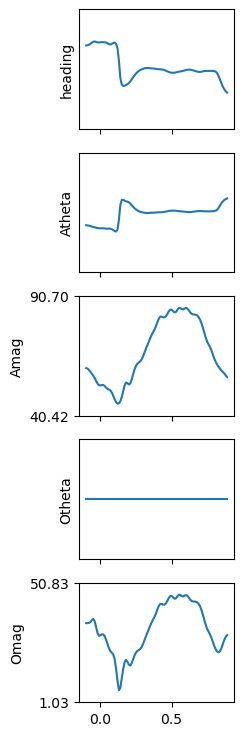

In [9]:
pfn_model.plot_stimulus()

In [10]:
keys = list(pfn_model.res.keys())
pfn_model.res['PFNd_amp'].shape

(2, 100)

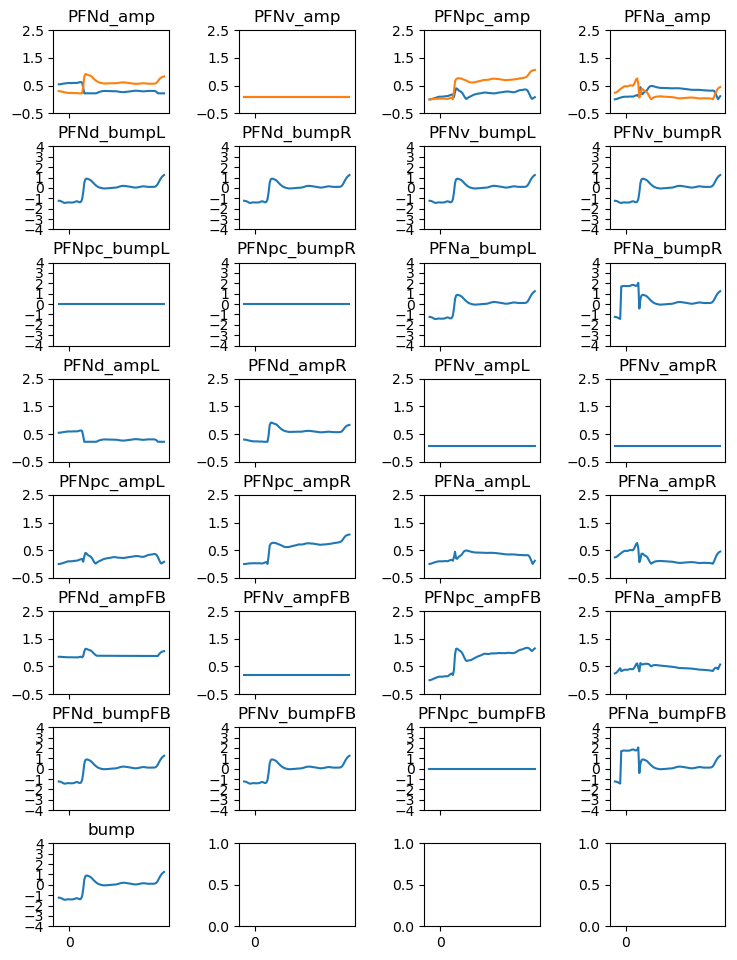

In [11]:
pfn_model.plot_bump(fig_size=0.7)

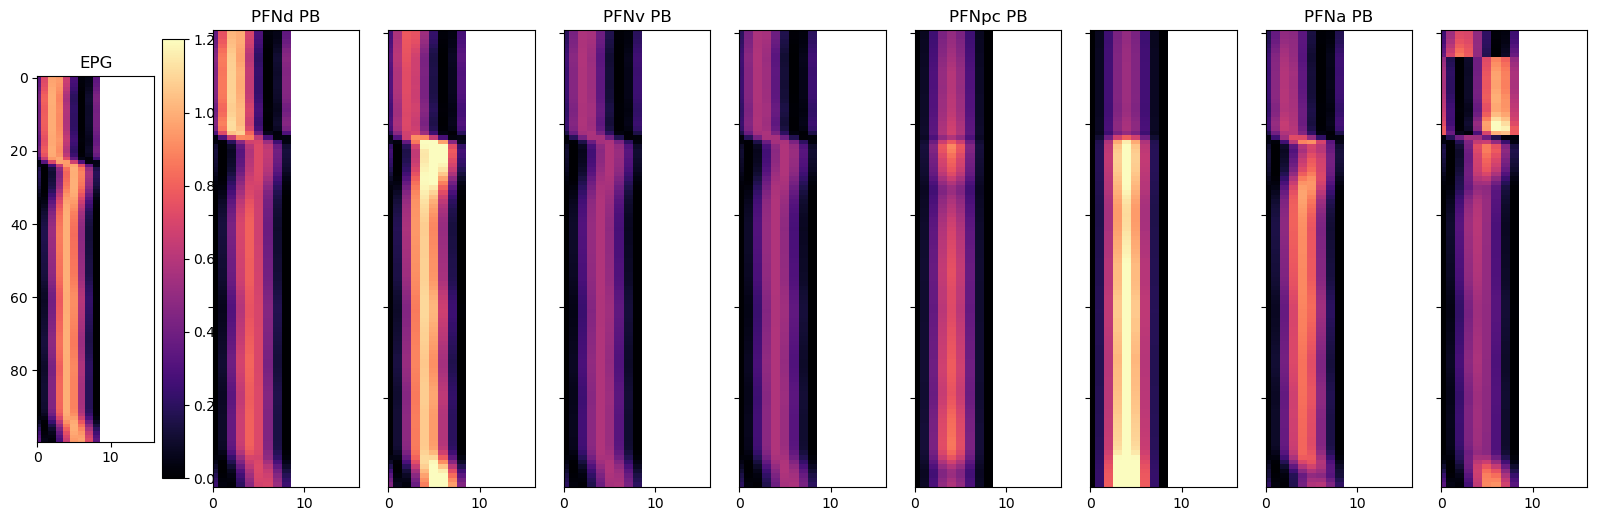

In [17]:
pfn_model.plot_heatmap(fig_size=20,cmap='magma')
plt.savefig('vBtraj61_heatmaps_with_magmacbar.svg')

ValueError: x and y must have same first dimension, but have shapes (128,) and (410,)

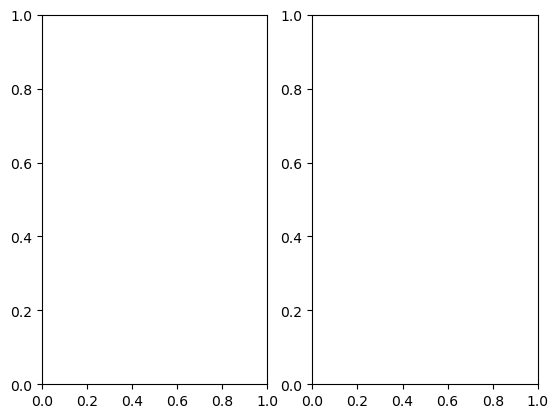

In [29]:
fig,ax = plt.subplots(1,2)
ax[0].plot(np.arange(1,129,step=1),abs(np.diff(stims['Amag'])))
ax[0].plot(pfn_model.res['PFNpc_ampL'])
ax[0].plot(pfn_model.res['PFNpc_ampR'])
ax[1].plot(stims['Amag'])